# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [2]:
# Install required libraries (uncomment if needed)
!pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hub pillow nltk

  Using cached wordcloud-1.9.6-cp310-cp310-win_amd64.whl.metadata (3.5 kB)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [4]:
# Load the dataset
import pandas as pd
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
## TODO: check on https://huggingface.co/datasets/SetFit/20_newsgroups how to load with pandas
df =  pd.read_json(
    "hf://datasets/SetFit/20_newsgroups/" + splits["train"],
    lines=True
)  # YOUR CODE HERE

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [6]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [7]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)
# YOUR CODE HERE
my_categories = ["rec.autos", "sci.space", "talk.politics.misc"]  # Replace with your choices

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['rec.autos', 'sci.space', 'talk.politics.misc']
Filtered dataset size: 1652

Distribution:
label_text
rec.autos             594
sci.space             593
talk.politics.misc    465
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

*[Write your answer here - minimum 3 sentences]*

I chose rec.autos, sci.space, and talk.politics.misc because they represent three clearly different domains: automobiles, science/technology, and politics. These categories are not closely related, which makes them ideal for comparing how vocabulary differs across technical, mechanical, and opinion-based discussions. I expect rec.autos to contain terms related to cars and engineering, sci.space to include more scientific and technical language, and talk.politics.misc to feature more argumentative and subjective wording. I also find these topics personally interesting because they cover real-world applications, scientific exploration, and societal issues, making the analysis more engaging and meaningful.

---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [8]:
# Example preprocessing function
# TODO: Complete the function as needed
def preprocess_text(text):
    """Basic text preprocessing."""
    # Lowercase
    text = text.lower() # YOUR CODE HERE
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text) # YOUR CODE HERE
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text) # YOUR CODE HERE
    # Remove numbers
    text = re.sub(r'\d+', '', text) # YOUR CODE HERE
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text) # YOUR CODE HERE
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip() # YOUR CODE HERE
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [9]:
# TODO: Complete this improved preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.
    
    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """
    # YOUR CODE HERE
    # Step 1: Basic cleaning (lowercase, remove emails, URLs, numbers, punctuation)
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)          # remove emails
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'\d+', '', text)              # remove numbers
    text = re.sub(r'[^\w\s]', '', text)          # remove punctuation
    # Step 2: Tokenize
    tokens = word_tokenize(text)
    # Step 3: Remove stop words
    tokens = [word for word in tokens if word not in stop_words]
    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    # Step 5: Remove short words (< 3 chars)
    tokens = [word for word in tokens if len(word) >= 3]
    # Step 6: Join back to string
    text = " ".join(tokens)
    return text  # Replace with your result

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [10]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
wondering anyone could enlighten car saw day door sport car looked late early called bricklin door really small addition front bumper separate rest body know anyone tellme model name engine spec year production car made history whatever info funky looking car please email


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

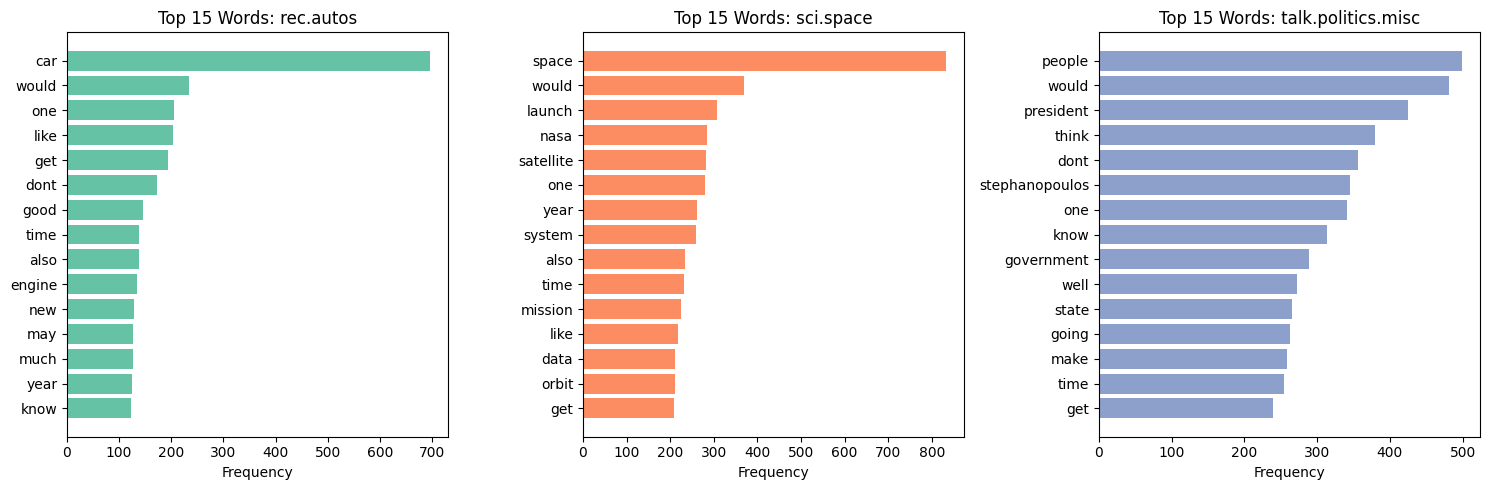

In [11]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)
    
    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

YOUR ANSWER:

Category 1 (rec.autos):
Unique words: car, engine, good

Category 2 (sci.space):
Unique words: space, nasa, orbit

Category 3 (talk.politics.misc):
Unique words: president, government, stephanopoulos

Shared words and explanation:
Shared words include would, one, like, get, know, time. These appear across multiple categories because they are common conversational words used in everyday language. Since the dataset consists of discussion-style posts, users naturally use these words regardless of the topic. Even after preprocessing, these words remain because they are not always removed as stop words and still occur frequently in natural communication.

Topic guessing analysis:
Yes, based only on the top words, it is possible to identify the topics of each category. In rec.autos, words like car and engine clearly indicate discussions about vehicles. In sci.space, terms such as space, nasa, and orbit strongly point to space science and exploration. In talk.politics.misc, words like president, government, and people suggest political discussions. This shows that even simple word frequency analysis can effectively reveal the main themes of different categories.

### C.2 Word Clouds

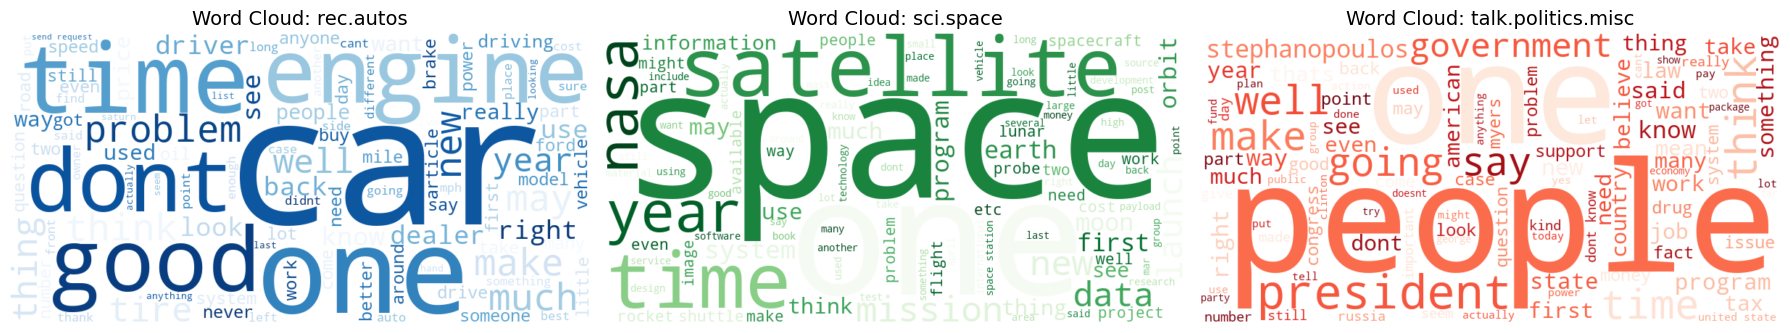

In [12]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)
    
    wordcloud = WordCloud(
        width=800, 
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**. 

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

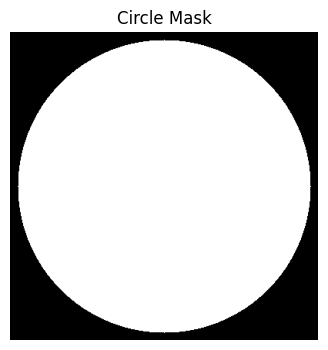

In [15]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

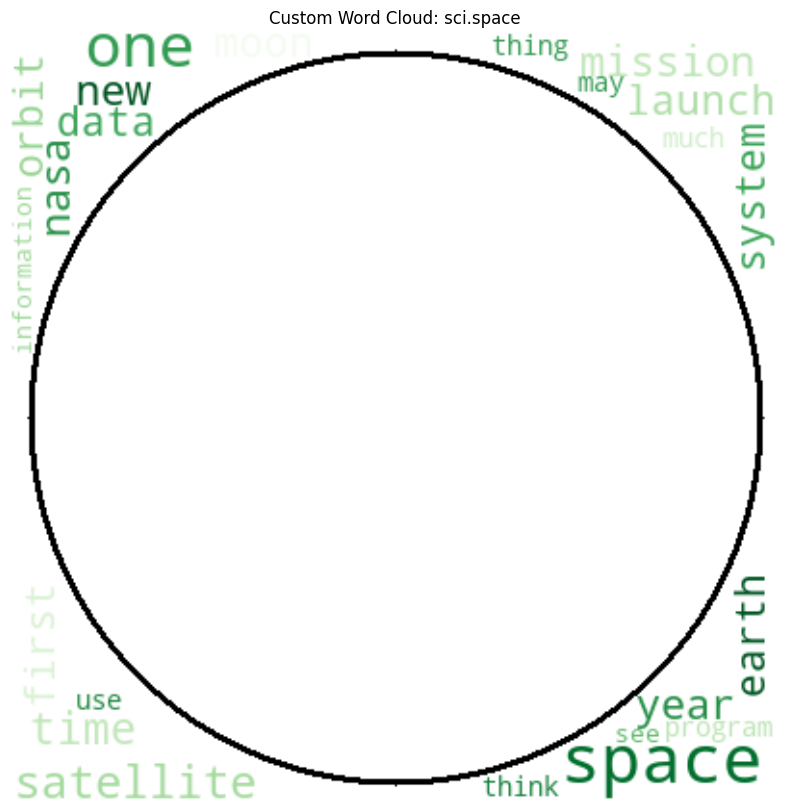

In [16]:
# TODO: Create a custom word cloud with a mask
# Choose ONE of your categories for this visualization

# YOUR CODE HERE
selected_category = "sci.space"  # Choose one of your categories

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Create word cloud with mask
# Hint: Use the mask parameter in WordCloud()
# wordcloud = WordCloud(..., mask=your_mask, ...).generate(text_combined)

wordcloud_masked =  WordCloud(
    width=800,
    height=800,
    background_color='white',
    colormap='Greens',
    mask=circle_mask,
    max_words=100,
    min_font_size=10,
    contour_width=2,
    contour_color='black'
).generate(text_combined)  # YOUR CODE HERE

# Display
plt.figure(figsize=(10, 10))
# YOUR CODE HERE - display the wordcloud
plt.imshow(wordcloud_masked, interpolation='bilinear')
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part D: Bag of Words (BoW) Representation 

In [17]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: Create BoW for Your Dataset

In [18]:
# TODO: Create a Bag of Words representation for your filtered dataset
# Use parameters: max_features=1000, min_df=5, max_df=0.95

# YOUR CODE HERE
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

# Fit and transform on your cleaned texts
bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])  # YOUR CODE HERE

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1652, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['able' 'access' 'accident' 'according' 'account' 'act' 'action'
 'activity' 'actually' 'add' 'addition' 'additional' 'address'
 'administration' 'advertising' 'aerospace' 'age' 'agency' 'ago' 'agree']


### Exercise D.2: Document Similarity with BoW

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Compute cosine similarity between documents
# Then find the 2 most similar documents and the 2 most different documents

# Compute similarity matrix
similarity_matrix = cosine_similarity(bow_matrix_full)  # YOUR CODE HERE

print(f"Similarity matrix shape: {similarity_matrix.shape}")

Similarity matrix shape: (1652, 1652)


In [20]:
# TODO: Find the 2 most similar documents (excluding self-similarity)
# Hint: Set diagonal to 0 or -1, then find argmax

# YOUR CODE HERE
sim_matrix = similarity_matrix.copy()

# Exclude self-similarity
np.fill_diagonal(sim_matrix, -1)

# Find indices of most similar pair
most_similar_idx = np.unravel_index(np.argmax(sim_matrix), sim_matrix.shape)
most_similar_score = sim_matrix[most_similar_idx]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (np.int64(258), np.int64(348))
Similarity score: 1.0

Document 1 category: rec.autos
Document 2 category: rec.autos


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?** 
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

The two most similar documents are both from the same category (rec.autos). This indicates that the Bag of Words representation is capturing category-specific vocabulary effectively, since documents within the same topic tend to use similar words.

After examining the original texts, the similarity likely comes from both documents discussing similar automobile-related topics, such as car features, models, or mechanical aspects. They may also share many of the same keywords like car, engine, dealer, or year, and could even contain very similar phrasing or repeated information. The similarity score of 1.0 suggests that the documents are either nearly identical or share almost exactly the same word counts, which can happen if posts are duplicated or very closely related.

The BoW similarity measure is meaningful in this case because it successfully identifies documents with very similar vocabulary. However, it has limitations because it only considers word frequency and ignores word order and context. This means two documents could have identical BoW representations even if their meanings differ slightly, so while the similarity is useful, it does not fully capture semantic meaning.

In [21]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
                    ^^^^^^^
Huh!  I though Beamers were IBM employees :-)


Document 2 (first 300 chars):



	Is the 24v LH under $16K, though?




**YOUR ANSWER:**

*[Write your analysis here - answer all 3 questions]*

1. Same or different category: Both documents are from the same category (rec.autos).

2. What makes them similar: Even though the texts are very short and appear quite different in wording, they likely share overlapping vocabulary related to automobiles or informal discussion style. Both texts are brief, conversational, and possibly part of similar discussion threads about cars. Because Bag of Words ignores word order and focuses only on word presence and counts, even a small overlap in common words (or very limited vocabulary overall due to short length) can result in identical or near-identical vector representations.

3. Is BoW meaningful here: The BoW similarity is not very meaningful in this case. The similarity score of 1.0 suggests the documents are identical in terms of word counts, but the actual texts are clearly different in meaning and content. This happens because both documents are extremely short, so the vocabulary is limited and may overlap in trivial ways. This highlights a key limitation of BoW: it ignores context, semantics, and word order, and can produce misleadingly high similarity scores for short or sparse texts.

---

## Part E: TF-IDF Representation

In [22]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [23]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [24]:
# TODO: Create TF-IDF representation for your dataset
# Use same parameters: max_features=1000, min_df=5, max_df=0.95

tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95 # YOUR PARAMETERS HERE
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])  # YOUR CODE HERE

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (1652, 1000)


In [25]:
# TODO: Find the top 10 most important words (highest TF-IDF) for each of your 3 categories

def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    # YOUR CODE HERE
    # 1. Get indices of documents in this category
    category_indices = df_filtered[df_filtered['label_text'] == category].index
    
    # 2. Get their TF-IDF vectors
    category_tfidf = tfidf_matrix_full[category_indices]
    
    # 3. Compute mean TF-IDF for each word across these documents
    mean_tfidf = np.asarray(category_tfidf.mean(axis=0)).flatten()
    
    # 4. Return top n words
    feature_names = tfidf_vectorizer_full.get_feature_names_out()
    top_indices = mean_tfidf.argsort()[::-1][:n]
    
    top_words = [(feature_names[i], mean_tfidf[i]) for i in top_indices]
    return top_words

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    print(top_words)


Top TF-IDF words for 'rec.autos':
[('car', np.float64(0.09890521327321174)), ('like', np.float64(0.031356697057224825)), ('would', np.float64(0.030918946753914087)), ('one', np.float64(0.027773995824638138)), ('get', np.float64(0.02615213299846435)), ('good', np.float64(0.025259582572625366)), ('engine', np.float64(0.025037487580680442)), ('new', np.float64(0.024089027182492773)), ('dont', np.float64(0.02303270838522211)), ('know', np.float64(0.02230035217118072))]

Top TF-IDF words for 'sci.space':
[('space', np.float64(0.06123351188067048)), ('would', np.float64(0.038369715129214645)), ('one', np.float64(0.02697025752554799)), ('like', np.float64(0.026778570796558043)), ('nasa', np.float64(0.02460832302058836)), ('launch', np.float64(0.024112317262168538)), ('orbit', np.float64(0.023816535253625176)), ('get', np.float64(0.02216567575040126)), ('moon', np.float64(0.020748698843807364)), ('year', np.float64(0.020738852899150974))]

Top TF-IDF words for 'talk.politics.misc':
[('people'

### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**

*[Write your comparative analysis here]*

1. Words in TF-IDF but not counts:
rec.autos: dont
sci.space: moon
talk.politics.misc: tax, law

These words appear in TF-IDF but not prominently in the word count charts because TF-IDF highlights words that are more distinctive to a category rather than just frequent.

2. Words in counts but not TF-IDF:
rec.autos: time, well, see
sci.space: satellite, system, mission
talk.politics.misc: going, well, say

These words appear in the count-based charts because they occur frequently, but TF-IDF downweights them since they are either common across documents or less distinctive for identifying the category.

3. Which method is better and why: TF-IDF better captures the “topic” of each category because it emphasizes words that are unique and informative rather than simply frequent. While Bag of Words highlights commonly used words, many of those words (such as would, one, and like) appear across multiple categories and do not help distinguish between them. TF-IDF reduces the importance of such common words and gives higher weight to more meaningful terms like nasa, orbit, tax, and law, which are more representative of their respective categories. Therefore, TF-IDF provides a more accurate and interpretable representation of the underlying topics.

---

## Part F: N-grams and Next Word Prediction

In [26]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [27]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [28]:
# TODO: Find the top 15 most common bigrams for each of your categories

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

# YOUR CODE HERE
# For each category:
# 1. Get the texts
# 2. Fit the bigram vectorizer
# 3. Find most common bigrams

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    
    # Fit the bigram vectorizer on this category's texts
    bigram_matrix = bigram_vectorizer.fit_transform(texts)
    
    # Sum counts across all documents in the category
    bigram_counts = np.asarray(bigram_matrix.sum(axis=0)).flatten()
    
    # Get bigram names
    bigram_names = bigram_vectorizer.get_feature_names_out()
    
    # Sort by count descending
    top_indices = bigram_counts.argsort()[::-1]
    top_bigrams = [(bigram_names[i], bigram_counts[i]) for i in top_indices[:15]]
    
    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams[:15]:
        print(f"  {bigram}: {count}")


Top bigrams for 'rec.autos':
  dont know: 26
  radar detector: 24
  would like: 21
  mailing list: 20
  year ago: 19
  new car: 18
  much better: 14
  sport car: 13
  look like: 13
  car driver: 12
  speed limit: 12
  sound like: 12
  oil change: 12
  dont think: 11
  car like: 11

Top bigrams for 'sci.space':
  space station: 69
  space shuttle: 56
  anonymous ftp: 37
  commercial space: 31
  remote sensing: 30
  launch vehicle: 27
  national space: 26
  nasa ames: 24
  air force: 23
  anyone know: 20
  space technology: 20
  black hole: 20
  space program: 20
  dont think: 19
  earth orbit: 19

Top bigrams for 'talk.politics.misc':
  dont know: 88
  united state: 82
  health care: 62
  white house: 56
  dont think: 53
  administration official: 53
  stephanopoulos dont: 49
  young people: 48
  working group: 36
  los angeles: 35
  stimulus package: 34
  stephanopoulos think: 33
  new york: 32
  stephanopoulos well: 32
  summer job: 32


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [29]:
# TODO: Build a bigram-based next word predictor

class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}   # {word1: {word2: count, ...}}
        self.unigram_counts = {}  # {word: count}
    
    def train(self, texts):
        """
        Train the model on a list of texts.
        
        Args:
            texts (list): List of preprocessed text strings
        """
        # 1. For each text, tokenize into words
        # 2. Count unigrams
        # 3. Count bigrams (word pairs)
        for text in texts:
            words = text.split()
            
            # Count unigrams
            for word in words:
                self.unigram_counts[word] = self.unigram_counts.get(word, 0) + 1
            
            # Count bigrams
            for i in range(len(words) - 1):
                word1, word2 = words[i], words[i + 1]
                
                if word1 not in self.bigram_counts:
                    self.bigram_counts[word1] = {}
                
                self.bigram_counts[word1][word2] = self.bigram_counts[word1].get(word2, 0) + 1
    
    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.
        
        Args:
            word (str): The input word
            top_n (int): Number of predictions to return
            
        Returns:
            list: List of (next_word, probability) tuples
        """
        # 1. Look up the word in bigram_counts
        if word not in self.bigram_counts:
            return []
        
        next_words = self.bigram_counts[word]
        
        # 2. Calculate probabilities: P(word2|word1) = count(word1, word2) / count(word1)
        total_after_word = sum(next_words.values())
        predictions = [
            (next_word, count / total_after_word)
            for next_word, count in next_words.items()
        ]
        
        # 3. Return top_n predictions sorted by probability
        predictions = sorted(predictions, key=lambda x: x[1], reverse=True)
        return predictions[:top_n]

# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [30]:
# Test your predictor with words relevant to your categories
# TODO: Choose 5 test words that are relevant to YOUR chosen categories

test_words =  ["car", "engine", "space", "nasa", "government"]  # Replace with your words

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    for next_word, prob in predictions:
        print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'car' ->
  driver: 0.018
  like: 0.016
  would: 0.014
  driven: 0.010
  one: 0.010

'engine' ->
  size: 0.025
  noise: 0.020
  compartment: 0.020
  cutoff: 0.015
  used: 0.015

'space' ->
  station: 0.081
  shuttle: 0.066
  program: 0.026
  technology: 0.024
  science: 0.022

'nasa' ->
  ames: 0.084
  center: 0.042
  budget: 0.024
  spacelink: 0.021
  select: 0.017

'government' ->
  agency: 0.034
  regulation: 0.026
  would: 0.020
  power: 0.014
  control: 0.014


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

1. Good predictions:
“space → station, shuttle” → These are very sensible because “space station” and “space shuttle” are common and meaningful phrases in the sci.space category.

“government → agency, regulation” → These are also strong predictions since government discussions often involve agencies and regulations, which fits the political context.
   
   Bad predictions:
“car → would, one” → These are not very meaningful because they are generic conversational words and do not specifically relate to automobiles.

“engine → cutoff” → This is a weak prediction because it is not a common or intuitive phrase compared to something like “engine power” or “engine performance.”
3. Limitations: The bigram model only considers one previous word when predicting the next word, so it lacks broader context. It also relies purely on frequency counts, meaning it can produce generic or less meaningful predictions when common words dominate. Additionally, it cannot handle unseen word combinations and does not understand semantics, so it may generate grammatically correct but contextually weak predictions.

4. Improvement ideas:
Use trigrams or higher-order n-grams to incorporate more context (e.g., considering the last two words instead of one).
Apply TF-IDF weighting or filtering to reduce the influence of common, less informative words.
Use more advanced models such as neural language models (e.g., RNNs, LSTMs, or transformers) to capture deeper context and meaning.

---

## Part G: Document Correlation Matrix

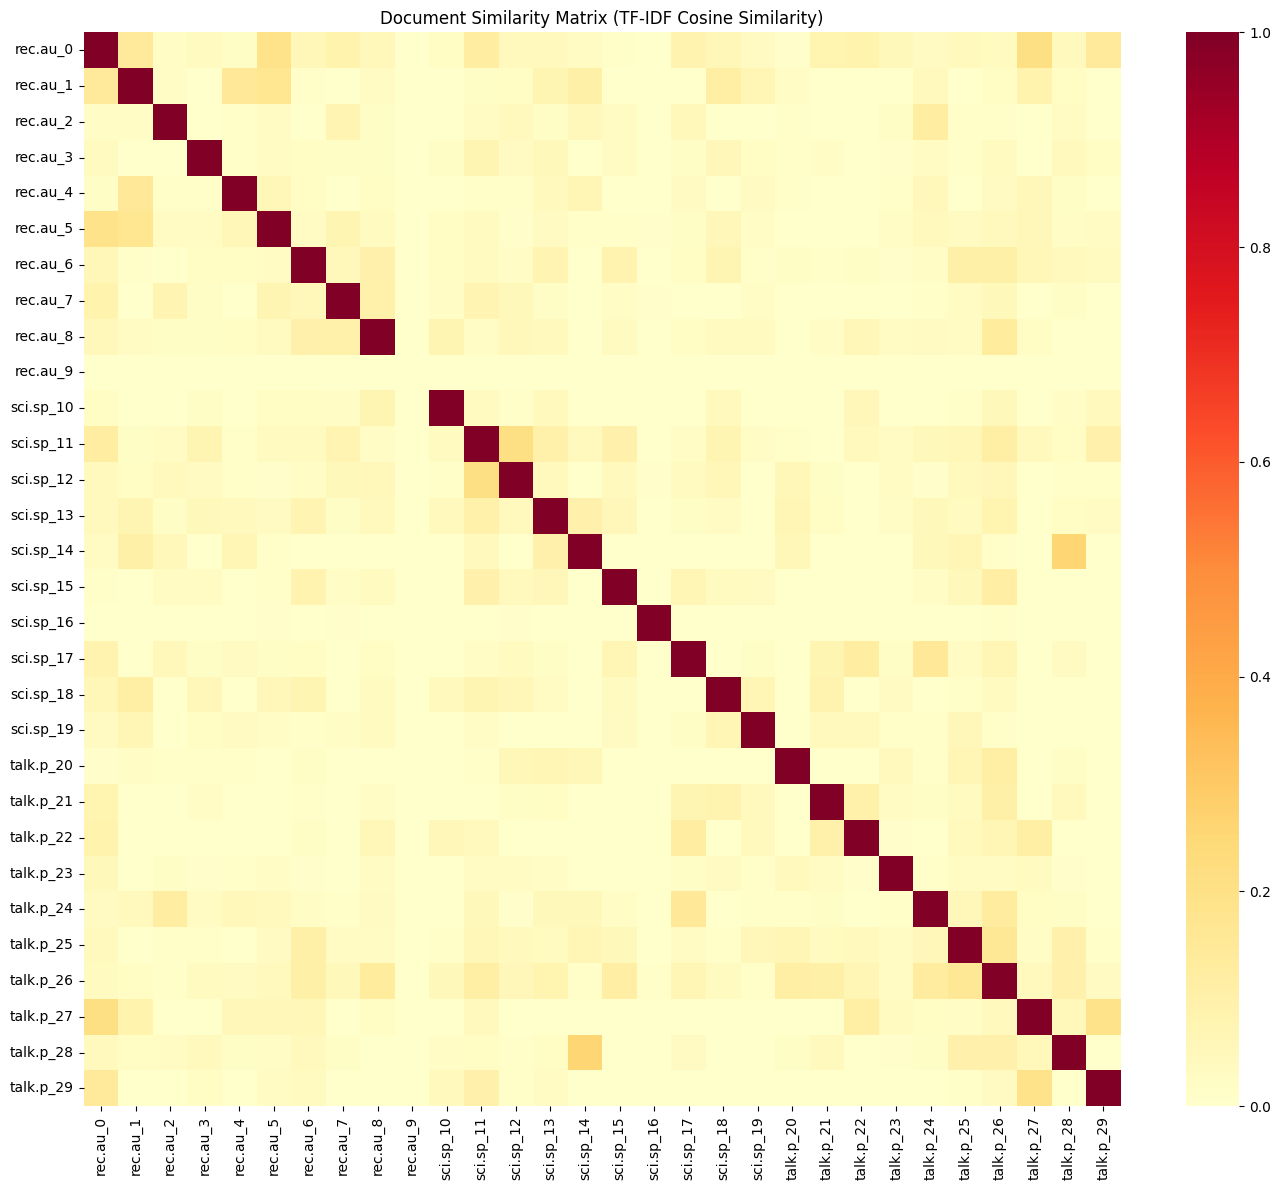

In [31]:
# TODO: Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import seaborn as sns

# Sample documents
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled, 
    xticklabels=labels, 
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**

1. Clustering observation: Yes, documents from the same category clearly cluster together. This is visible as brighter blocks along the diagonal within each category group (e.g., the first 10 for rec.autos, next 10 for sci.space, and last 10 for talk.politics.misc). These brighter regions indicate higher similarity within the same category, showing that documents in each category share similar vocabulary patterns.

2. Most/Least similar category pairs: The most similar categories appear to be rec.autos and sci.space, as there are slightly more moderate similarity values between their blocks compared to others. This may be because both categories contain some technical or descriptive language (e.g., discussions of systems, models, or specifications).

The least similar pair is sci.space and talk.politics.misc, as their cross-category regions are mostly very light, indicating low similarity. This makes sense because one is technical/scientific while the other is more opinion-based and political.

3. Surprising similarities: Yes, there are a few lighter-orange spots between documents from different categories, indicating some unexpected similarity. These could be explained by shared general-purpose words (e.g., would, one, know) or overlapping discussion styles. Additionally, some topics may slightly overlap—for example, government discussions about space programs or policies could create similarity between sci.space and talk.politics.misc. These similarities highlight that while categories are distinct, natural language often contains shared vocabulary across domains.

---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
